# Motility Induced Phase Separation in 2D

## Overview

### Questions

* How does **motility-induced phase separation (MIPS)** emerge in systems of purely repulsive active particles?

### Objectives

* Implement a 2D simulation of **Active Brownian Particles (ABPs)** to study MIPS.
* Apply a Brownian integrator with rotational diffusion and zero thermal noise to explore activity-driven clustering.
* Reduce the system to two dimensions to suppress out-of-plane fluctuations and highlight the core mechanisms behind active phase separation.


## Boilerplate Code

In [1]:
import hoomd
import itertools
import freud

import gsd.hoomd

import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "MIPS.gsd")
![ -e "$fn" ] && rm "$fn"

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.outline_width = 0.04
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=np.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=np.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(0, 0, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

## Introducing Motility Induced Phase Separation

In this tutorial, we replicate much of the set up as in [the previous section](02-Active-Brownian-Particles.ipynb) where we introduced active Brownian particle simulations. However, here, we now aim to understand an important collective behavior that colections of active particles may present called **motility-induced phase separation (MIPS)** where a system of purely repulsive active particles exhibits a phase transition to gas-liquid coexistance. MIPS systems provide clear visual confirmation of active behavior, as the emergence of distinct dense and dilute regions—absent in equivalent passive systems—confirms that particles are correctly self-propelling and interacting out of equilibrium. 

For purely repulsive particles, the most important parameters to control when a repulsive ative system phase separates in this way is the activity of the particle and the density of the system. In this simulation, we will control these two parameters to drive our system into a MIPS state.

## Set up the Simulation

In this section, to simplify the system and focus on essential mechanisms driving MIPS, we conduct our simulations in two dimensions. This is achieved by constraining particle motion to the xy-plane (box.dimensions = 2) while maintaining a minimal but nonzero box thickness in the z-direction. Using a 2D geometry reduces removes out-of-plane fluctuations, making it easier to observe clustering behavior, density fluctuations, and phase separation driven purely by activity and crowding effects. For the set up of this tutorial, this is the only major difference between the simulation in 3D that we did in the previous section.

We will first initialize a system of spherical particles with a given particle density, in a 2D array. We then save an initial snapshot of the current state of the system. Even in 2D simulations, HOOMD expects positions to be 3D (x, y, z), so here we pad position to have a third column of zeros. Additionally, HOOMD requires a 3D box definition, so to establish a 2D box we set Lz=0 in our definition.

In [4]:
rho = 0.3 # particle area density
simseed = 1

m = 50
N_particles = m**2
K = np.ceil(N_particles ** (1 / 2))
L = (N_particles / rho)**(1 / 2)
spacing = L / K
x = np.linspace(-L / 2, L / 2, int(K), endpoint=False)

position_2D = np.array(list(itertools.product(x, repeat=2))) + [spacing / 2, spacing / 2]
position_3D = np.hstack([position_2D[:N_particles], np.zeros((N_particles, 1))])

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position_3D[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, 0, 0, 0, 0,]
frame.particles.types = ['A']
frame.particles.mass = [1] * N_particles
frame.particles.orientation = [[1, 0, 0, 0]] * N_particles

with gsd.hoomd.open(name='lattice.gsd', mode='w') as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials. 

True. Lz = 0 in the simulation box.


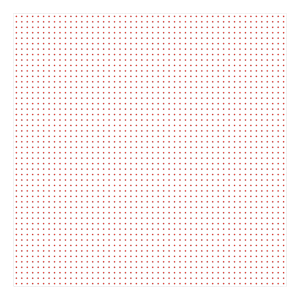

In [5]:
cpu = hoomd.device.CPU()
sim = hoomd.Simulation(device=cpu, seed=simseed)
state = sim.create_state_from_gsd(filename='lattice.gsd')

if hoomd.Box.is2D:
    print('True. Lz = 0 in the simulation box.')
    
render(sim.state.get_snapshot())

## Defining Interactions in an Active Particle system

Add a short range Lennard Jones (WCA) pair potential interactions between particles.

In [7]:
LJ_sigma = 1
LJ_epsilon = 1

cell = hoomd.md.nlist.Cell(buffer=0.4, exclusions=['body'])
wca = hoomd.md.pair.LJ(nlist=cell, default_r_cut=(2**(1/6))*LJ_sigma, default_r_on=0.0, mode='shift')
wca.params[('A', 'A')] = {'sigma': LJ_sigma, 'epsilon': LJ_epsilon}

integrator.forces.append(wca)

Set up the OverdampedViscous integrator.

In [8]:
kT = 0
gamma = 1

filter_all = hoomd.filter.All()
overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_all)
overdamped.gamma.default = gamma
overdamped.gamma_r.default = [gamma,gamma,gamma]

integrator = hoomd.md.Integrator(dt=0.001, integrate_rotational_dof=False)
sim.operations.integrator = integrator
integrator.methods.append(overdamped)

## Peclet number, activity and MIPS

A key quantity that you may want to control in your simulations is the **Péclet number (Pe)**. This is a key dimensionless parameter in active matter that quantifies the relative strength of persistent active motion versus random thermal diffusion. It’s critical for determining whether MIPS occurs. For spherical ABPs in 2D this is typically defined as Pe = v_0 sigma / D_r where 
- v_0 = self-propulsion speed (active force per friction)
- sigma = particle diameter (typically = 1 in reduced units)
- and D_r = rotational diffusion coefficient

As you saw in the previous tutorial, in hoomd, the propulsion velocity is controlled by applying an active force to particles in the system. The relationship between these quantities is v_0 = F_active / gamma where gamma is the  translational drag coefficient (often = 1 in overdamped Brownian dynamics). D_r is typically set directly in the integrator as rotational diffusion. 

Activity (often quantified by self-propulsion speed or Peclet number) drives persistent motion that breaks equilibrium detailed balance. Higher activity can induce clustering even at densities too low for passive phase separation, triggering motility-induced phase separation. 

A general rule of thumb is (still need to cite and double check):
- Pe < 10: mostly homogeneous, little clustering
- Pe ≈ 20–80: MIPS starts to emerge (depending on density)
- Pe > 100: strong phase separation likely

Below, we set our Peclet number to 20, which will put us in the general regime where we can expect MIPS above certain intermediate densities according to the rule of thumb set in section . Since, we have previously set gamma =1, we will do this by setting our active force = 2 and rotation diffusion = 0.1, so our peclet number is 20 according to the definition we gave in section 01. 

In [9]:
activity = 2

active = hoomd.md.force.Active(filter=filter_all)
active.active_force['A'] = (activity,0,0)
active.active_torque['A'] = (0,0,0)

integrator.forces.append(active)

rotational_diffusion_updater = active.create_diffusion_updater(
    trigger=1, rotational_diffusion = 0.1)
sim.operations += rotational_diffusion_updater

Run the Simulation and get initial snapshot

In [10]:
logger = hoomd.logging.Logger(['particle','constraint'])
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(100)), filename='MIPS.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=hoomd.filter.All())

sim.operations += gsd_oper
sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)

Thermalize the system

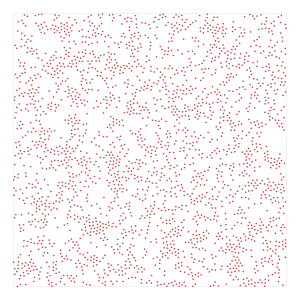

In [11]:
sim.run(10000)
gsd_oper.flush()
render(sim.state.get_snapshot())

## Density and 2D MIPS

Now that we have set up a 2D simulation of hard spheres of a reasonably high Peclet number, it is easy for us to induce MIPS by increasing the system's denisty. Density controls how crowded the particles are, affecting collision frequency and cluster formation. Increasing density generally promotes phase separation by enhancing particle interactions. MIPS usually emerges above a critical packing fraction around 0.3–0.4 for sufficiently high activity (Peclet number).

By systematically varying both density and activity, we can map out the phase diagram and identify regimes where the system spontaneously separates into dense clusters and dilute gas-like regions.

For the sake of this tutorial, we will compress our 2D system with Pe=20 to visualize MIPS by following a very similar compression method as in the Molecular dynamics tutorials (cite here).


In [12]:
initial_box = sim.state.box
initial_rho = sim.state.N_particles / (initial_box.Lx * initial_box.Ly)

final_rho = 0.55
final_area = sim.state.N_particles / final_rho
final_L = final_area**(1/2)

final_box = hoomd.Box.from_box(initial_box)  # make a copy of initial_box
final_box.Lx = final_L
final_box.Ly = final_L
final_box.Lz = 0

ramp = hoomd.variant.Ramp(A=0, B=1, t_start=sim.timestep, t_ramp=20000)
box_resize_trigger = hoomd.trigger.Periodic(10)


interpolated_box = hoomd.variant.box.Interpolate(
    initial_box=initial_box, final_box=final_box, variant=ramp)

box_resize = hoomd.update.BoxResize(
    trigger=hoomd.trigger.Periodic(10),
    box=interpolated_box,
    filter=hoomd.filter.All()
)

sim.operations.updaters.append(box_resize)

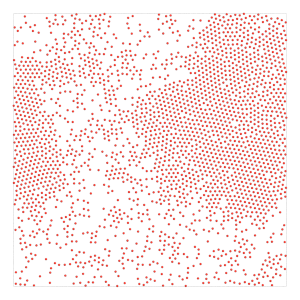

In [13]:
sim.run(200000)
gsd_oper.flush()

render(sim.state.get_snapshot())

By visual inspection, we can see gas-liquid coexistance that we expect from a characteristic MIPS. There are numerous other more quantitive ways to document this behavior as well that we can do using tools like freud (cite), for instance.

At densities above ~0.7, the system approaches a nearly jammed or glassy regime where dynamics slow down significantly. 

To visualize this, we will compress our system to an even higher density, noting that rho cannot exceed rho*, the close packed density. Here, we repeat the earlier compression process below to compress to to an area density of 0.9:

In [18]:
initial_box = sim.state.box
initial_rho = sim.state.N_particles / (initial_box.Lx * initial_box.Ly)

final_rho = 0.9
final_area = sim.state.N_particles / final_rho
final_L = final_area**(1/2)

final_box = hoomd.Box.from_box(initial_box)  # make a copy of initial_box
final_box.Lx = final_L
final_box.Ly = final_L
final_box.Lz = 0

ramp = hoomd.variant.Ramp(A=0, B=1, t_start=sim.timestep, t_ramp=20000)
box_resize_trigger = hoomd.trigger.Periodic(10)


interpolated_box = hoomd.variant.box.Interpolate(
    initial_box=initial_box, final_box=final_box, variant=ramp)

box_resize = hoomd.update.BoxResize(
    trigger=hoomd.trigger.Periodic(10),
    box=interpolated_box,
    filter=hoomd.filter.All()
)

sim.operations.updaters.append(box_resize)

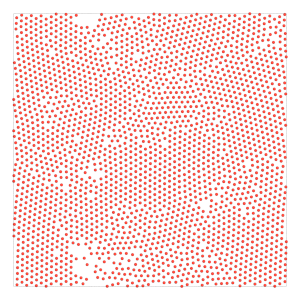

In [19]:
sim.run(100000)
gsd_oper.flush()

render(sim.state.get_snapshot())